In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('../data/StudentsPerformance.csv')

In [5]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape


(1000, 8)

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [13]:
print("categories in gender:", df['gender'].unique())
print("categories in race/ethnicity:", df['race/ethnicity'].unique())
print("categories in parental level of education:", df['parental level of education'].unique())
print("categories in lunch:", df['lunch'].unique())
print("categories in test preparation course:", df['test preparation course'].unique())
 

categories in gender: ['female' 'male']
categories in race/ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
categories in parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in lunch: ['standard' 'free/reduced']
categories in test preparation course: ['none' 'completed']


In [15]:
numeric_features = [feature for feature in df.columns if df[feature].dtype!='O']
categorical_features = [feature for feature in df.columns if df[feature].dtype=='O']
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['math score', 'reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


# add total and avg score columns

In [16]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average Score'] = df['Total Score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [18]:
readingfull=df[df['reading score']==100]['Average Score'].count()
print("number of students with full marks in reading:", readingfull)
writingfull=df[df['writing score']==100]['Average Score'].count()
print("number of students with full marks in writing:", writingfull)
mathfull=df[df['math score']==100]['Average Score'].count()
print("number of students with full marks in math:", mathfull)

number of students with full marks in reading: 17
number of students with full marks in writing: 14
number of students with full marks in math: 7


In [19]:
readinglessthan20=df[df['reading score']<20]['Average Score'].count()
print("number of students with less than 20 marks in reading:", readinglessthan20)
writinglessthan20=df[df['writing score']<20]['Average Score'].count()
print("number of students with less than 20 marks in writing:", writinglessthan20)
mathlessthan20=df[df['math score']<20]['Average Score'].count()
print("number of students with less than 20 marks in math:", mathlessthan20)

number of students with less than 20 marks in reading: 1
number of students with less than 20 marks in writing: 3
number of students with less than 20 marks in math: 4


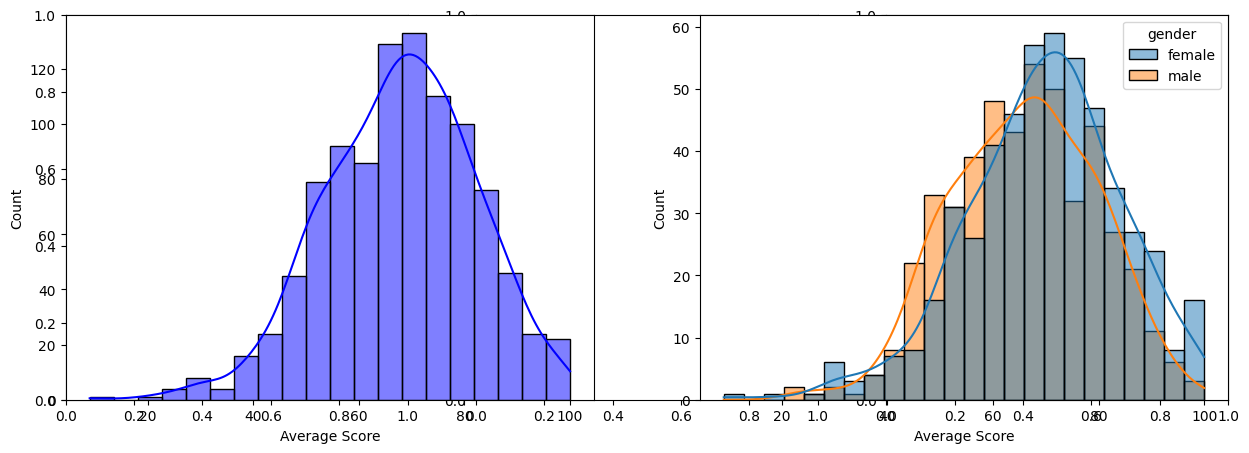

In [24]:
fig,axs=plt.subplots(1,3,figsize=(15,5))
plt.subplot(121)
sns.histplot(data=df,x='Average Score',bins=20,kde=True,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='Average Score',kde=True,hue='gender')
plt.show()

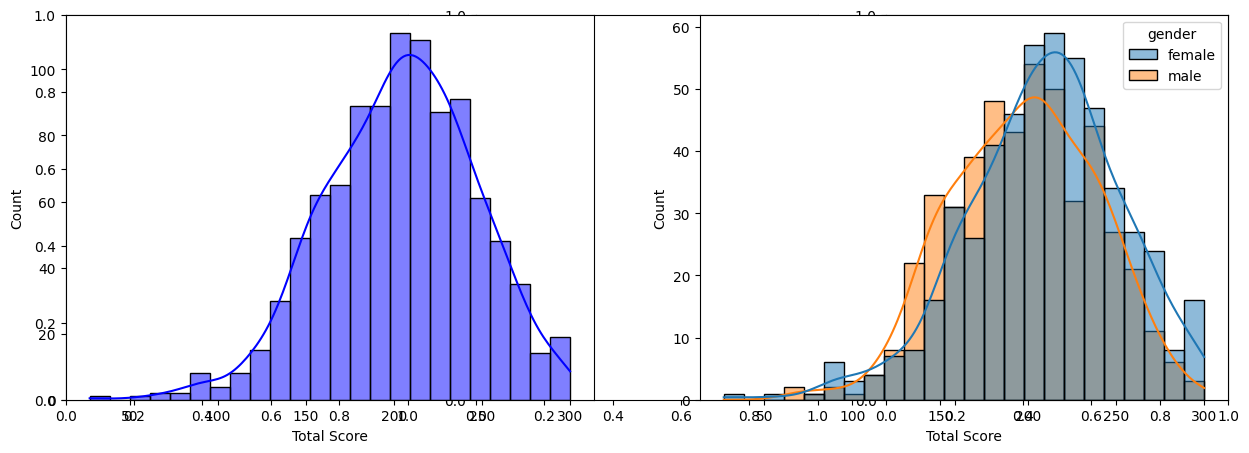

In [26]:
fig,axs=plt.subplots(1,3,figsize=(15,5))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',kde=True,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='Total Score',kde=True,hue='gender')
plt.show()